# 🐧 Clasificación de Pingüinos Palmer
## Exploración progresiva: K-Means → SVM → Árbol → RLM → Neurona

**Dataset:** Palmer Penguins (seaborn)  
**Objetivo:** Clasificar la especie (`Adelie`, `Chinstrap`, `Gentoo`) a partir de características físicas  
**Enfoque:** Cada modelo se entrena, evalúa y justifica por qué el siguiente es necesario

---
> 📌 **Estructura:** `Bloque 0` Glosario · `Bloque 1` EDA · `Bloque 2` Preprocesamiento  
> `Bloque 3` K-Means · `Bloque 4` SVM · `Bloque 5` Árbol · `Bloque 6` RLM  
> `Bloque 7` Neurona · `Bloque 8` Comparativa · `Bloque 9` Inferencia · `Bloque 10` Conclusiones

---
## 📖 Bloque 0: Glosario de Términos Clave

| Término | Definición |
|---------|-----------|
| **Feature / Característica** | Variable de entrada para predecir (ej: longitud del pico) |
| **Target / Etiqueta** | Variable que queremos predecir (ej: especie) |
| **Train / Test** | Train = datos para aprender · Test = datos para evaluar (nunca vistos en entrenamiento) |
| **Normalización** | Transforma features a media 0 y desv. estándar 1 para que ninguna variable domine |
| **One-Hot Encoding** | Convierte variables categóricas en columnas binarias (0 o 1) |
| **Overfitting** | El modelo memoriza el dataset de entrenamiento y falla con datos nuevos |
| **Accuracy** | Porcentaje de predicciones correctas sobre el total |
| **Balanced Accuracy** | Accuracy promediada por clase — útil cuando las clases están desbalanceadas |
| **F1-Score (Macro)** | Media armónica entre Precision y Recall |
| **Precision** | De todas las veces que predije clase X, ¿cuántas realmente eran X? |
| **Recall** | De todos los ejemplos reales de clase X, ¿cuántos detecté? |
| **Matriz de Confusión** | Tabla de aciertos y errores por clase. Diagonal principal = correcto. |
| **Silhouette Score** | Qué tan bien definidos están los clusters (−1 a 1) |
| **Kernel (SVM)** | Función que transforma features para separar clases no lineales |
| **Softmax** | Convierte salidas numéricas en probabilidades que suman 1 |
| **Backpropagation** | Ajusta pesos en redes neuronales propagando el error hacia atrás |
| **Early Stopping** | Detiene el entrenamiento cuando el modelo deja de mejorar en validación |
| **PCA** | Reducción de dimensionalidad para visualizar datos multidimensionales en 2D |

---
## 🎯 El Problema

El dataset **Palmer Penguins** contiene mediciones físicas de 344 pingüinos de 3 especies recolectadas en el Archipiélago Palmer (Antártida):

- 🐧 **Adelie** — La más pequeña y abundante; pico corto y redondeado
- 🐧 **Chinstrap** — Se distingue por una línea negra bajo el mentón
- 🐧 **Gentoo** — La más grande; pico naranja y aletas largas

| Variable | Tipo | Rol |
|----------|------|-----|
| `species` | Categórica | ✅ **Variable objetivo** |
| `island` | Categórica | Feature → One-Hot |
| `bill_length_mm` | Numérica | Feature → Normalización |
| `bill_depth_mm` | Numérica | Feature → Normalización |
| `flipper_length_mm` | Numérica | Feature → Normalización |
| `body_mass_g` | Numérica | Feature → Normalización |
| `sex` | Categórica | Feature → One-Hot |

> 💡 Equivalente **Iris Dataset**: features continuas, 3 clases

In [70]:
# ============================================================
# IMPORTS
# ============================================================
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Preprocesamiento
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA

# Modelos
from sklearn.cluster import KMeans
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier

# Metricas
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, f1_score,
    precision_score, recall_score, confusion_matrix,
    classification_report, silhouette_score
)

print("Imports cargados correctamente")

Imports cargados correctamente


---
## 📊 Bloque 1: Exploración del Dataset (EDA)

Antes de cualquier modelo hay que **conocer los datos**: distribución de clases, valores nulos, relaciones entre variables.


In [71]:
df = sns.load_dataset("penguins")

print(f"Dimensiones: {df.shape[0]} filas x {df.shape[1]} columnas")
print(f"\nValores nulos por columna:")
print(df.isnull().sum())
print(f"\nDistribucion de especies:")
print(df['species'].value_counts())
print(f"\nTipos de datos:")
print(df.dtypes)

display(df.head())

Dimensiones: 344 filas x 7 columnas

Valores nulos por columna:
species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64

Distribucion de especies:
species
Adelie       152
Gentoo       124
Chinstrap     68
Name: count, dtype: int64

Tipos de datos:
species                  str
island                   str
bill_length_mm       float64
bill_depth_mm        float64
flipper_length_mm    float64
body_mass_g          float64
sex                      str
dtype: object


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


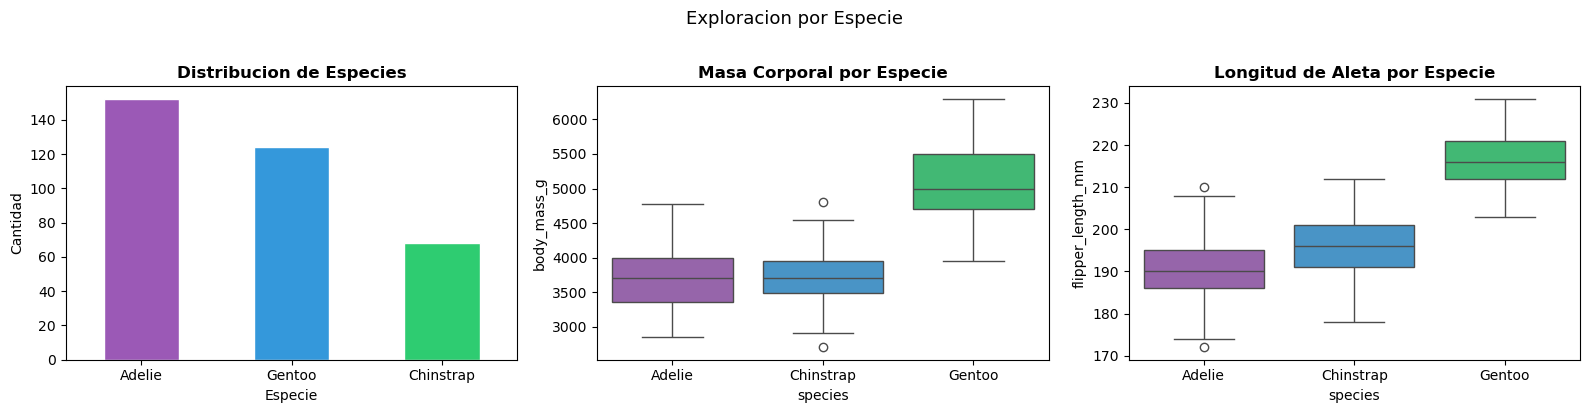

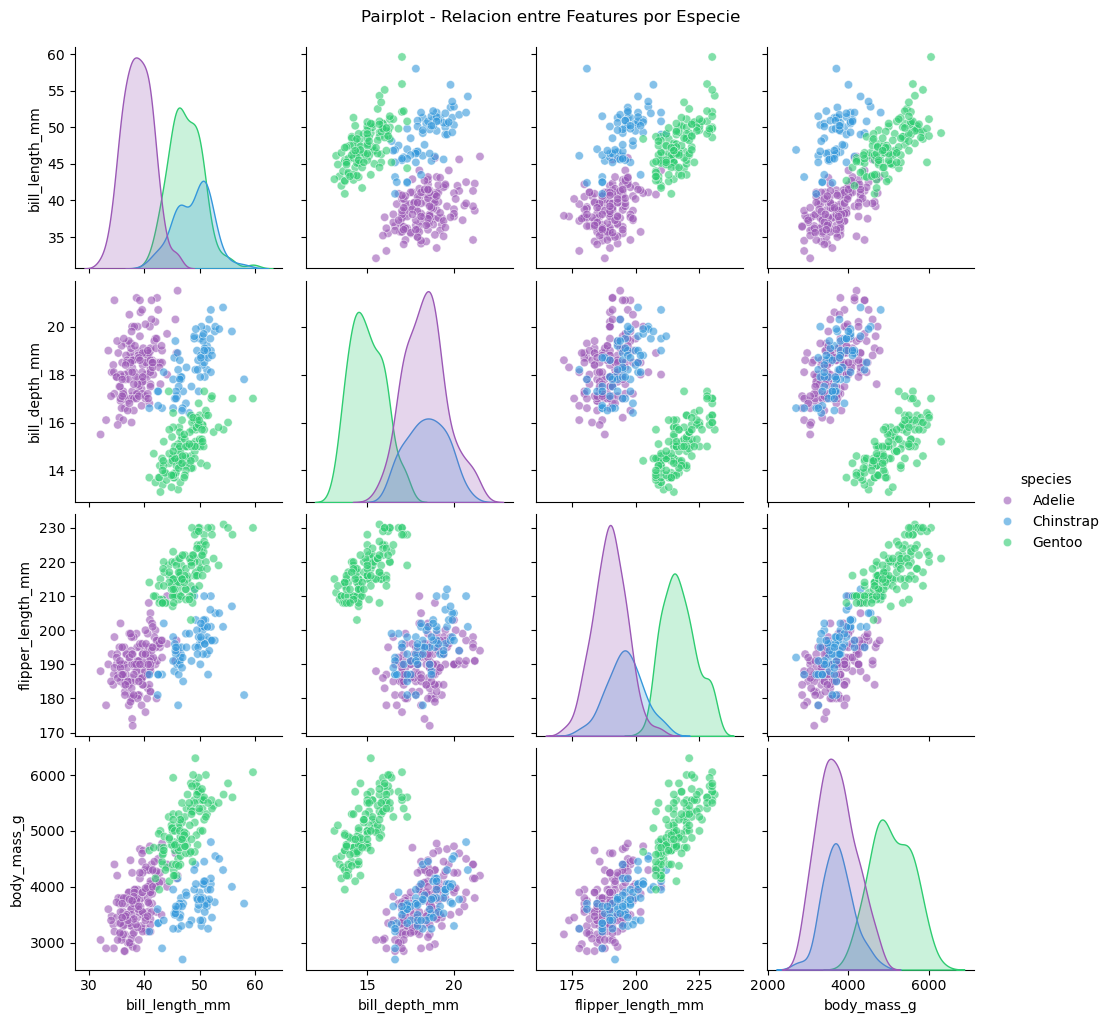


============ INTERPRETACION VISUAL DEL EDA ============

Lo que se observa en las graficas:

GRUPOS Y SEPARABILIDAD
- Gentoo forma un grupo notablemente separado del resto.
  Su masa corporal y longitud de aleta son claramente mayores que las otras dos especies.
- Adelie y Chinstrap presentan mayor cercania entre si, especialmente en masa corporal y longitud de aleta.
  La variable que mejor las distingue es bill_length_mm.

VARIABLES MAS DISCRIMINANTES
- body_mass_g: Gentoo es claramente mayor.
- flipper_length_mm: Gentoo destaca; Adelie es la menor.
- bill_length_mm: Chinstrap tiene pico mas largo para su tamano, lo que la separa de Adelie.
- bill_depth_mm: Adelie y Chinstrap son similares;
  Gentoo tiene el pico mas angosto en profundidad.

CORRELACION ENTRE VARIABLES
- Existe correlacion positiva entre masa corporal y longitud de aleta: a mayor aleta, generalmente mayor masa.
  Algunos modelos (SVM, MLP) aprovechan estas relaciones.

IMPLICACION PARA MACHINE LEARNING
- El problema

In [72]:
# -- Distribucion y boxplots ----------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

df['species'].value_counts().plot(
    kind='bar', ax=axes[0],
    color=['#9b59b6','#3498db','#2ecc71'], edgecolor='white')
axes[0].set_title('Distribucion de Especies', fontweight='bold')
axes[0].set_xlabel('Especie'); axes[0].set_ylabel('Cantidad')
axes[0].tick_params(axis='x', rotation=0)

sns.boxplot(data=df, x='species', y='body_mass_g',
            palette=['#9b59b6','#3498db','#2ecc71'], ax=axes[1])
axes[1].set_title('Masa Corporal por Especie', fontweight='bold')

sns.boxplot(data=df, x='species', y='flipper_length_mm',
            palette=['#9b59b6','#3498db','#2ecc71'], ax=axes[2])
axes[2].set_title('Longitud de Aleta por Especie', fontweight='bold')

plt.suptitle('Exploracion por Especie', fontsize=13, y=1.02)
plt.tight_layout(); plt.show()

# -- Pairplot ---------------------------------------------------
sns.pairplot(df, hue='species',
             vars=['bill_length_mm','bill_depth_mm','flipper_length_mm','body_mass_g'],
             palette=['#9b59b6','#3498db','#2ecc71'],
             plot_kws={'alpha': 0.6}, diag_kind='kde')
plt.suptitle('Pairplot - Relacion entre Features por Especie', y=1.02)
plt.show()
print("""
============ INTERPRETACION VISUAL DEL EDA ============

Lo que se observa en las graficas:

GRUPOS Y SEPARABILIDAD
- Gentoo forma un grupo notablemente separado del resto.
  Su masa corporal y longitud de aleta son claramente mayores que las otras dos especies.
- Adelie y Chinstrap presentan mayor cercania entre si, especialmente en masa corporal y longitud de aleta.
  La variable que mejor las distingue es bill_length_mm.

VARIABLES MAS DISCRIMINANTES
- body_mass_g: Gentoo es claramente mayor.
- flipper_length_mm: Gentoo destaca; Adelie es la menor.
- bill_length_mm: Chinstrap tiene pico mas largo para su tamano, lo que la separa de Adelie.
- bill_depth_mm: Adelie y Chinstrap son similares;
  Gentoo tiene el pico mas angosto en profundidad.

CORRELACION ENTRE VARIABLES
- Existe correlacion positiva entre masa corporal y longitud de aleta: a mayor aleta, generalmente mayor masa.
  Algunos modelos (SVM, MLP) aprovechan estas relaciones.

IMPLICACION PARA MACHINE LEARNING
- El problema NO es trivial: Gentoo es facil de identificar, pero Adelie y Chinstrap tienen traslape moderado.
- Los modelos deberan aprender la combinacion especifica de variables que distingue cada especie.
- Se espera que los modelos supervisados logren alta precision, pero con algunos errores entre Adelie y Chinstrap.
======================================================
""")

### 🔗 Matriz de Correlación

Antes de preprocesar, analizamos qué tan relacionadas están las variables numéricas entre sí.
Esto nos ayuda a entender qué features aportan información independiente y cuáles son redundantes.

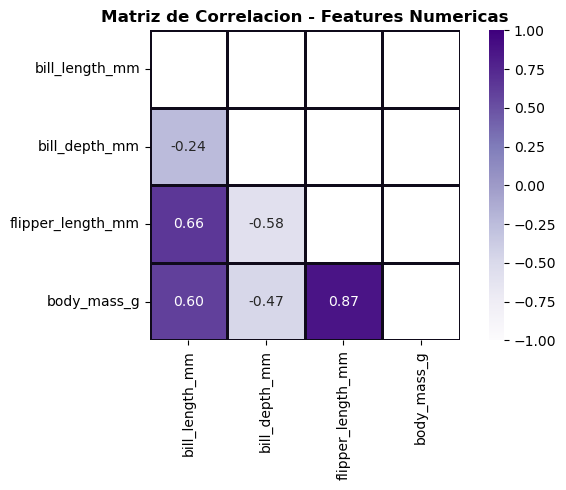


Como leer la matriz de correlacion:

  Valor cercano a  1.0 : correlacion positiva fuerte
                         (si una sube, la otra tambien sube)
  Valor cercano a -1.0 : correlacion negativa fuerte
                         (si una sube, la otra baja)
  Valor cercano a  0.0 : sin correlacion lineal aparente

OBSERVACIONES en Palmer Penguins:
  - flipper_length_mm y body_mass_g tienen correlacion alta positiva.
    Esto coincide con lo que vimos en los boxplots del EDA:
    los pinguinos mas grandes (Gentoo) tienen aletas mas largas.
  - bill_length_mm tiene correlacion moderada con las anteriores.
  - bill_depth_mm tiene correlacion baja o negativa con las otras.
    Eso significa que aporta informacion independiente y util.

IMPLICACION:
  Variables con alta correlacion entre si pueden ser redundantes.
  Variables con baja correlacion entre si aportan informacion
  complementaria y son mas valiosas para el modelo.



In [73]:
# -- Matriz de correlacion -- solo features numericas --------
numeric_cols = ['bill_length_mm','bill_depth_mm','flipper_length_mm','body_mass_g']
corr = df[numeric_cols].dropna().corr()

plt.figure(figsize=(7, 5))
mask = np.zeros_like(corr, dtype=bool)
mask[np.triu_indices_from(mask)] = True   # ocultamos el triangulo superior (es simetrico)

sns.heatmap(corr, annot=True, fmt='.2f', cmap='Purples',
            square=True, linewidths=0.8, linecolor='#0f0a1a',
            vmin=-1, vmax=1, mask=mask,
            annot_kws={'size': 10})
plt.title('Matriz de Correlacion - Features Numericas', fontweight='bold')
plt.tight_layout(); plt.show()

print("""
Como leer la matriz de correlacion:

  Valor cercano a  1.0 : correlacion positiva fuerte
                         (si una sube, la otra tambien sube)
  Valor cercano a -1.0 : correlacion negativa fuerte
                         (si una sube, la otra baja)
  Valor cercano a  0.0 : sin correlacion lineal aparente

OBSERVACIONES en Palmer Penguins:
  - flipper_length_mm y body_mass_g tienen correlacion alta positiva.
    Esto coincide con lo que vimos en los boxplots del EDA:
    los pinguinos mas grandes (Gentoo) tienen aletas mas largas.
  - bill_length_mm tiene correlacion moderada con las anteriores.
  - bill_depth_mm tiene correlacion baja o negativa con las otras.
    Eso significa que aporta informacion independiente y util.

IMPLICACION:
  Variables con alta correlacion entre si pueden ser redundantes.
  Variables con baja correlacion entre si aportan informacion
  complementaria y son mas valiosas para el modelo.
""")

---
## ⚙️ Bloque 2: Preprocesamiento Unificado

Preparamos los datos **una sola vez** para todos los modelos.

### Pasos:
1. **Eliminar NaN** — los modelos no toleran valores faltantes
2. **Codificar el target** — `species` → `0`, `1`, `2`
3. **One-Hot Encoding** — `island` y `sex` → columnas binarias
4. **Train/Test Split** — 80/20, estratificado por clase
5. **StandardScaler** — ajustado *solo* con datos de entrenamiento

---

> **¿Por qué eliminar NaN y no reemplazarlos con 0?**  
> Porque los NaN son mediciones físicas. Un `0` significaría "este pingüino tiene pico de 0 mm y pesa 0 gramos" — biológicamente imposible. El modelo lo aprendería como dato real y generaría predicciones erróneas.  

> **¿Por qué escalar DESPUÉS del split?**  
> Para evitar **data leakage**: si el scaler ve los datos de test durante el ajuste, el modelo "conoce" información que debería ser desconocida, inflando artificialmente las métricas.

In [74]:
# -- 1. Limpiar NaN ------------------------------------------------
df_clean = df.dropna().reset_index(drop=True)
print(f"Filas originales: {len(df)} | Despues de limpiar NaN: {len(df_clean)} ({len(df)-len(df_clean)} eliminadas)")

# -- 2. Codificar target -------------------------------------------
le = LabelEncoder()
y = le.fit_transform(df_clean['species'])
class_names = le.classes_
print(f"\nCodificacion: {dict(enumerate(class_names))}")

# -- 3. One-Hot Encoding ------------------------------------------
df_features = df_clean.drop(columns=['species'])
df_encoded  = pd.get_dummies(df_features, columns=['island', 'sex'], drop_first=False)
feature_names = df_encoded.columns.tolist()
print(f"\nFeatures tras encoding ({len(feature_names)} columnas):")
print(feature_names)

# -- 4. Convertir a numpy -----------------------------------------
X_raw = df_encoded.values.astype(float)

# -- 5. Split antes de escalar ------------------------------------
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.2, random_state=42, stratify=y
)

# -- 6. Escalar solo con train ------------------------------------
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test  = scaler.transform(X_test_raw)

print(f"\nTrain: {X_train.shape} | Test: {X_test.shape}")
print(f"Clases en train: {dict(zip(class_names, np.bincount(y_train)))}")
print(f"Clases en test:  {dict(zip(class_names, np.bincount(y_test)))}")

Filas originales: 344 | Despues de limpiar NaN: 333 (11 eliminadas)

Codificacion: {0: 'Adelie', 1: 'Chinstrap', 2: 'Gentoo'}

Features tras encoding (9 columnas):
['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g', 'island_Biscoe', 'island_Dream', 'island_Torgersen', 'sex_Female', 'sex_Male']

Train: (266, 9) | Test: (67, 9)
Clases en train: {'Adelie': np.int64(117), 'Chinstrap': np.int64(54), 'Gentoo': np.int64(95)}
Clases en test:  {'Adelie': np.int64(29), 'Chinstrap': np.int64(14), 'Gentoo': np.int64(24)}


In [75]:
# ============================================================
# FUNCIONES AUXILIARES REUTILIZABLES
# ============================================================

resultados = {}   # Acumula metricas para la tabla comparativa

def plot_confusion_matrix(y_true, y_pred, title):
    """Grafica la matriz de confusion e imprime como leerla."""
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
                xticklabels=class_names, yticklabels=class_names, ax=ax)
    ax.set_xlabel('Prediccion', fontsize=12)
    ax.set_ylabel('Real', fontsize=12)
    ax.set_title(title, fontsize=13, fontweight='bold')
    plt.tight_layout(); plt.show()

    diagonal = np.diag(cm)
    total    = cm.sum()
    aciertos = diagonal.sum()
    print(f"\nComo leer esta matriz:")
    print(f"  La diagonal principal = predicciones correctas.")
    print(f"  Valores fuera de diagonal = errores (confusion entre clases).")
    print(f"  Total aciertos: {aciertos}/{total} ({aciertos/total*100:.1f}%)")
    for i, cls in enumerate(class_names):
        errores = cm[i].sum() - cm[i, i]
        print(f"  - {cls}: {cm[i,i]} correctos, {errores} confundidos")


def print_metrics(y_true, y_pred, model_name):
    """Imprime metricas, las interpreta y las guarda en resultados."""
    acc  = accuracy_score(y_true, y_pred)
    bacc = balanced_accuracy_score(y_true, y_pred)
    f1   = f1_score(y_true, y_pred, average='macro')
    pre  = precision_score(y_true, y_pred, average='macro')
    rec  = recall_score(y_true, y_pred, average='macro')

    print(f"\n{'='*54}")
    print(f"  Metricas - {model_name}")
    print(f"{'='*54}")
    print(f"  Accuracy         : {acc:.4f}  ({acc*100:.1f}%)")
    print(f"  Balanced Accuracy: {bacc:.4f}  ({bacc*100:.1f}%)")
    print(f"  F1-Macro         : {f1:.4f}")
    print(f"  Precision        : {pre:.4f}")
    print(f"  Recall           : {rec:.4f}")
    print(f"{'='*54}")

    diff = abs(acc - bacc)
    if diff > 0.03:
        print(f"  Nota: Accuracy y Balanced Accuracy difieren {diff:.2%}.")
        print(f"  Esto sugiere que el modelo favorece alguna clase mayoritaria.")
    else:
        print(f"  Accuracy y Balanced Accuracy son similares: el modelo no favorece clases mayoritarias de forma significativa.")
        print(f"  ")

    if acc >= 0.95:
        print("  Desempeño excelente para este dataset.")
    elif acc >= 0.85:
        print("  Buen desempeño, con margen de mejora.")
    else:
        print("  Desempeño limitado - este modelo tiene dificultades.")

    resultados[model_name] = {
        'Accuracy':  round(acc, 4),
        'Bal.Acc':   round(bacc, 4),
        'F1-Macro':  round(f1, 4),
        'Precision': round(pre, 4),
        'Recall':    round(rec, 4)
    }
    return acc, f1


print("Funciones auxiliares listas")

Funciones auxiliares listas


---
## 🔵 Bloque 3: K-Means

### ¿Qué es K-Means?
**Aprendizaje no supervisado** — no usa etiquetas. Agrupa los datos en K clusters minimizando la distancia al centroide.

### ¿Cómo funciona?
1. Inicializa K centroides
2. Asigna cada punto al centroide más cercano
3. Recalcula centroides como promedio del cluster
4. Repite hasta convergencia

### ¿Por qué empezamos aquí?
Para ver si las especies se separan **naturalmente** sin usar etiquetas.

### Métricas
- **Silhouette Score** (−1 a 1): qué tan compactos y separados están los clusters
- **Inercia**: suma de distancias al cuadrado al centroide

Silhouette Score: 0.3975  (1.0 = clusters perfectos)
Inercia (train) : 1079.49

  Metricas - K-Means
  Accuracy         : 0.7910  (79.1%)
  Balanced Accuracy: 0.6667  (66.7%)
  F1-Macro         : 0.6019
  Precision        : 0.5581
  Recall           : 0.6667
  Nota: Accuracy y Balanced Accuracy difieren 12.44%.
  Esto sugiere que el modelo favorece alguna clase mayoritaria.
  Desempeño limitado - este modelo tiene dificultades.


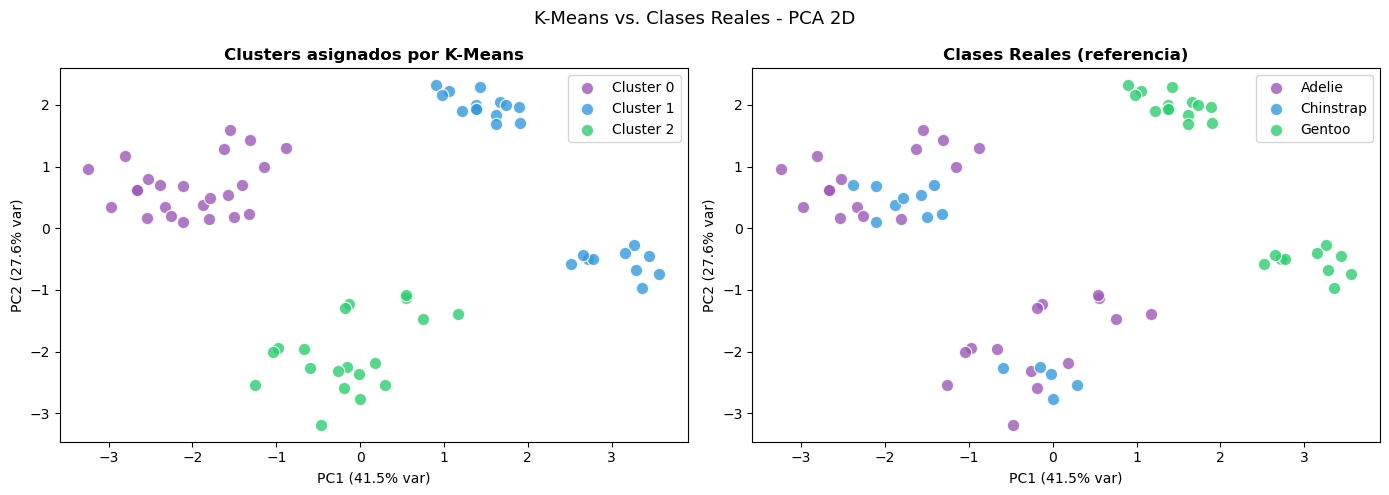

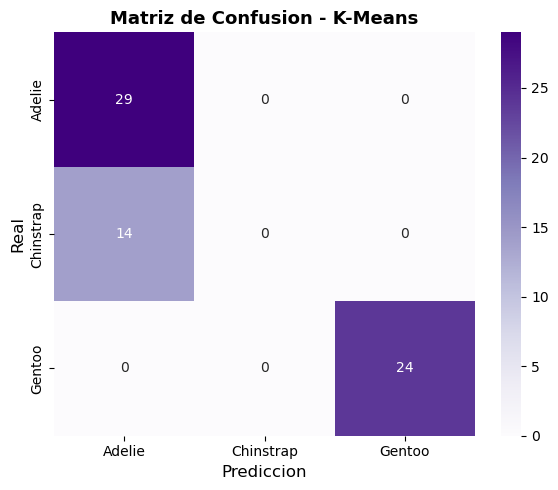


Como leer esta matriz:
  La diagonal principal = predicciones correctas.
  Valores fuera de diagonal = errores (confusion entre clases).
  Total aciertos: 53/67 (79.1%)
  - Adelie: 29 correctos, 0 confundidos
  - Chinstrap: 0 correctos, 14 confundidos
  - Gentoo: 24 correctos, 0 confundidos


In [76]:
# -- Entrenamiento -----------------------------------------------
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans.fit(X_train)
clusters_test = kmeans.predict(X_test)

# -- Mapeo clusters -> clases reales ------------------------------
# K-Means asigna etiquetas arbitrarias (0,1,2) sin saber que especie es cual.
# Para evaluar, mapeamos cada cluster a la clase real mas frecuente en el.
# IMPORTANTE: Este mapeo requiere conocer y_test, lo que solo es posible en un contexto de evaluacion. 
# En produccion real (sin etiquetas), no podriamos hacer este paso -- esa es la limitacion de K-Means.
label_map = {}
for cluster_id in range(3):
    mask = clusters_test == cluster_id
    if mask.sum() > 0:
        label_map[cluster_id] = int(np.bincount(y_test[mask]).argmax())
    else:
        label_map[cluster_id] = cluster_id

y_pred_kmeans = np.array([label_map[c] for c in clusters_test])

# -- Metricas ----------------------------------------------------
sil = silhouette_score(X_test, clusters_test)
print(f"Silhouette Score: {sil:.4f}  (1.0 = clusters perfectos)")
print(f"Inercia (train) : {kmeans.inertia_:.2f}")

print_metrics(y_test, y_pred_kmeans, "K-Means")

# -- Visualizacion PCA 2D ----------------------------------------
pca = PCA(n_components=2, random_state=42)
X_test_2d = pca.fit_transform(X_test)
palette = ['#9b59b6', '#3498db', '#2ecc71']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i in range(3):
    mask = clusters_test == i
    axes[0].scatter(X_test_2d[mask, 0], X_test_2d[mask, 1],
                    c=palette[i], label=f'Cluster {i}', alpha=0.8, edgecolors='white', s=80)
axes[0].set_title('Clusters asignados por K-Means', fontweight='bold')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)')
axes[0].legend()

for i, name in enumerate(class_names):
    mask = y_test == i
    axes[1].scatter(X_test_2d[mask, 0], X_test_2d[mask, 1],
                    c=palette[i], label=name, alpha=0.8, edgecolors='white', s=80)
axes[1].set_title('Clases Reales (referencia)', fontweight='bold')
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)')
axes[1].legend()

plt.suptitle('K-Means vs. Clases Reales - PCA 2D', fontsize=13)
plt.tight_layout(); plt.show()

plot_confusion_matrix(y_test, y_pred_kmeans, "Matriz de Confusion - K-Means")

### ⚠️ Limitaciones de K-Means → ¿Por qué necesitamos algo más?

1. **No supervisado:** No usa etiquetas. El mapeo cluster → especie requiere conocer las etiquetas reales — algo que en producción real no tendríamos.
2. **Asume clusters esféricos:** Sesgado hacia clusters de tamaño y forma similar.
3. **Sin probabilidades:** Solo asigna grupos, sin confianza ni certeza.

> 💡 Usemos las etiquetas reales para aprender el **hiperplano óptimo** entre clases — **SVM**.

---
## 🔴 Bloque 4: Support Vector Machine (SVM)

### ¿Qué es SVM?
Busca el **hiperplano óptimo** que maximiza el margen entre clases. Con `kernel='rbf'` transforma el espacio para separar clases no lineales.

### ¿Cómo funciona?
1. Identifica los puntos más cercanos al límite (**vectores de soporte**)
2. Maximiza el margen entre esos puntos y el hiperplano
3. Kernel RBF: transforma a mayor dimensión donde las clases son separables

### Ventajas sobre K-Means
- ✅ Supervisado: aprende de las etiquetas reales
- ✅ Robusto al overfitting por el principio de margen máximo


  Metricas - SVM (kernel RBF)
  Accuracy         : 0.9851  (98.5%)
  Balanced Accuracy: 0.9885  (98.9%)
  F1-Macro         : 0.9827
  Precision        : 0.9778
  Recall           : 0.9885
  Accuracy y Balanced Accuracy son similares: el modelo no favorece clases mayoritarias de forma significativa.
  
  Desempeño excelente para este dataset.


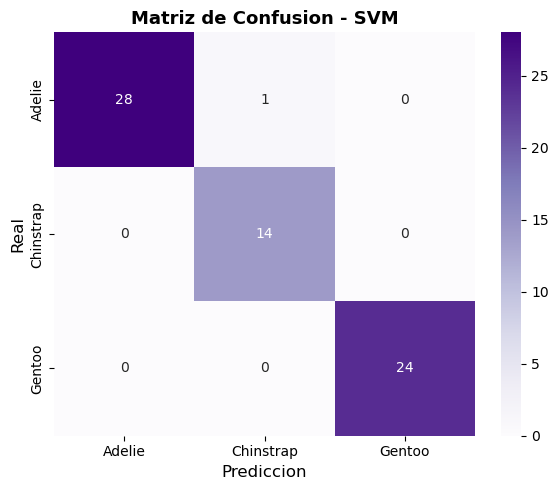


Como leer esta matriz:
  La diagonal principal = predicciones correctas.
  Valores fuera de diagonal = errores (confusion entre clases).
  Total aciertos: 66/67 (98.5%)
  - Adelie: 28 correctos, 1 confundidos
  - Chinstrap: 14 correctos, 0 confundidos
  - Gentoo: 24 correctos, 0 confundidos

Reporte por clase:
              precision    recall  f1-score   support

      Adelie       1.00      0.97      0.98        29
   Chinstrap       0.93      1.00      0.97        14
      Gentoo       1.00      1.00      1.00        24

    accuracy                           0.99        67
   macro avg       0.98      0.99      0.98        67
weighted avg       0.99      0.99      0.99        67



In [77]:
svm = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42, probability=True)
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)

print_metrics(y_test, y_pred_svm, "SVM (kernel RBF)")
plot_confusion_matrix(y_test, y_pred_svm, "Matriz de Confusion - SVM")

print("\nReporte por clase:")
print(classification_report(y_test, y_pred_svm, target_names=class_names))

### ⚠️ Limitaciones de SVM → ¿Por qué necesitamos algo más?

1. **Caja negra:** No puede explicar "¿por qué este pingüino es Gentoo?" en términos de las features originales.
2. **Sin reglas legibles:** No genera criterios interpretables como "si aleta > 210 mm entonces Gentoo".

> 💡 Necesitamos un modelo con **reglas de decisión claras y visualizables** — **Árbol de Decisión**.

---
## 🟢 Bloque 5: Árbol de Decisión

### ¿Qué es?
Aprende **reglas if-then-else** sobre las features. Completamente interpretable: cada predicción sigue un camino de condiciones legibles.

### Ventajas sobre SVM
- ✅ 100% interpretable
- ✅ No requiere normalización
- ✅ Visualizable como diagrama

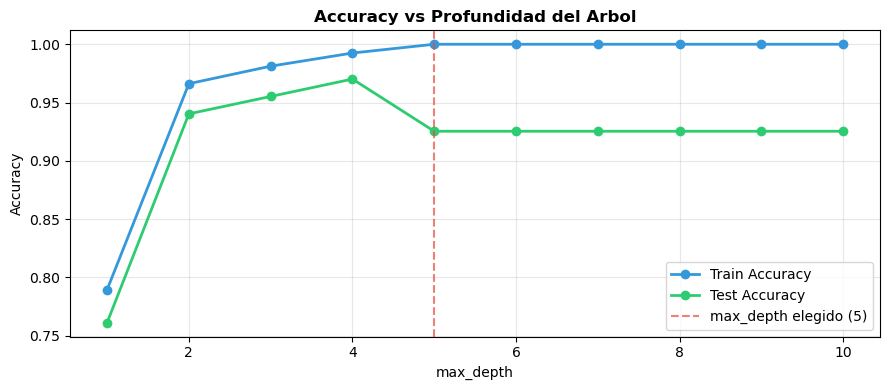

Por que max_depth=5?
  A partir de depth 5, Test Accuracy se estabiliza o baja.
  Profundidades mayores aumentan Train pero no Test: eso es OVERFITTING.
  max_depth=5 es el punto de equilibrio entre complejidad y generalizacion.

  Metricas - Arbol de Decision
  Accuracy         : 0.9552  (95.5%)
  Balanced Accuracy: 0.9607  (96.1%)
  F1-Macro         : 0.9518
  Precision        : 0.9468
  Recall           : 0.9607
  Accuracy y Balanced Accuracy son similares: el modelo no favorece clases mayoritarias de forma significativa.
  
  Desempeño excelente para este dataset.


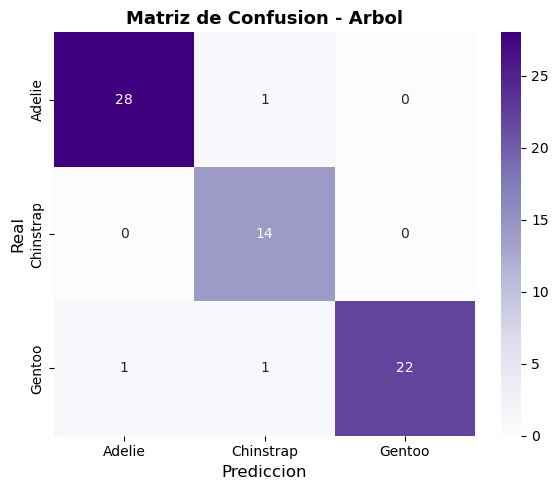


Como leer esta matriz:
  La diagonal principal = predicciones correctas.
  Valores fuera de diagonal = errores (confusion entre clases).
  Total aciertos: 64/67 (95.5%)
  - Adelie: 28 correctos, 1 confundidos
  - Chinstrap: 14 correctos, 0 confundidos
  - Gentoo: 22 correctos, 2 confundidos


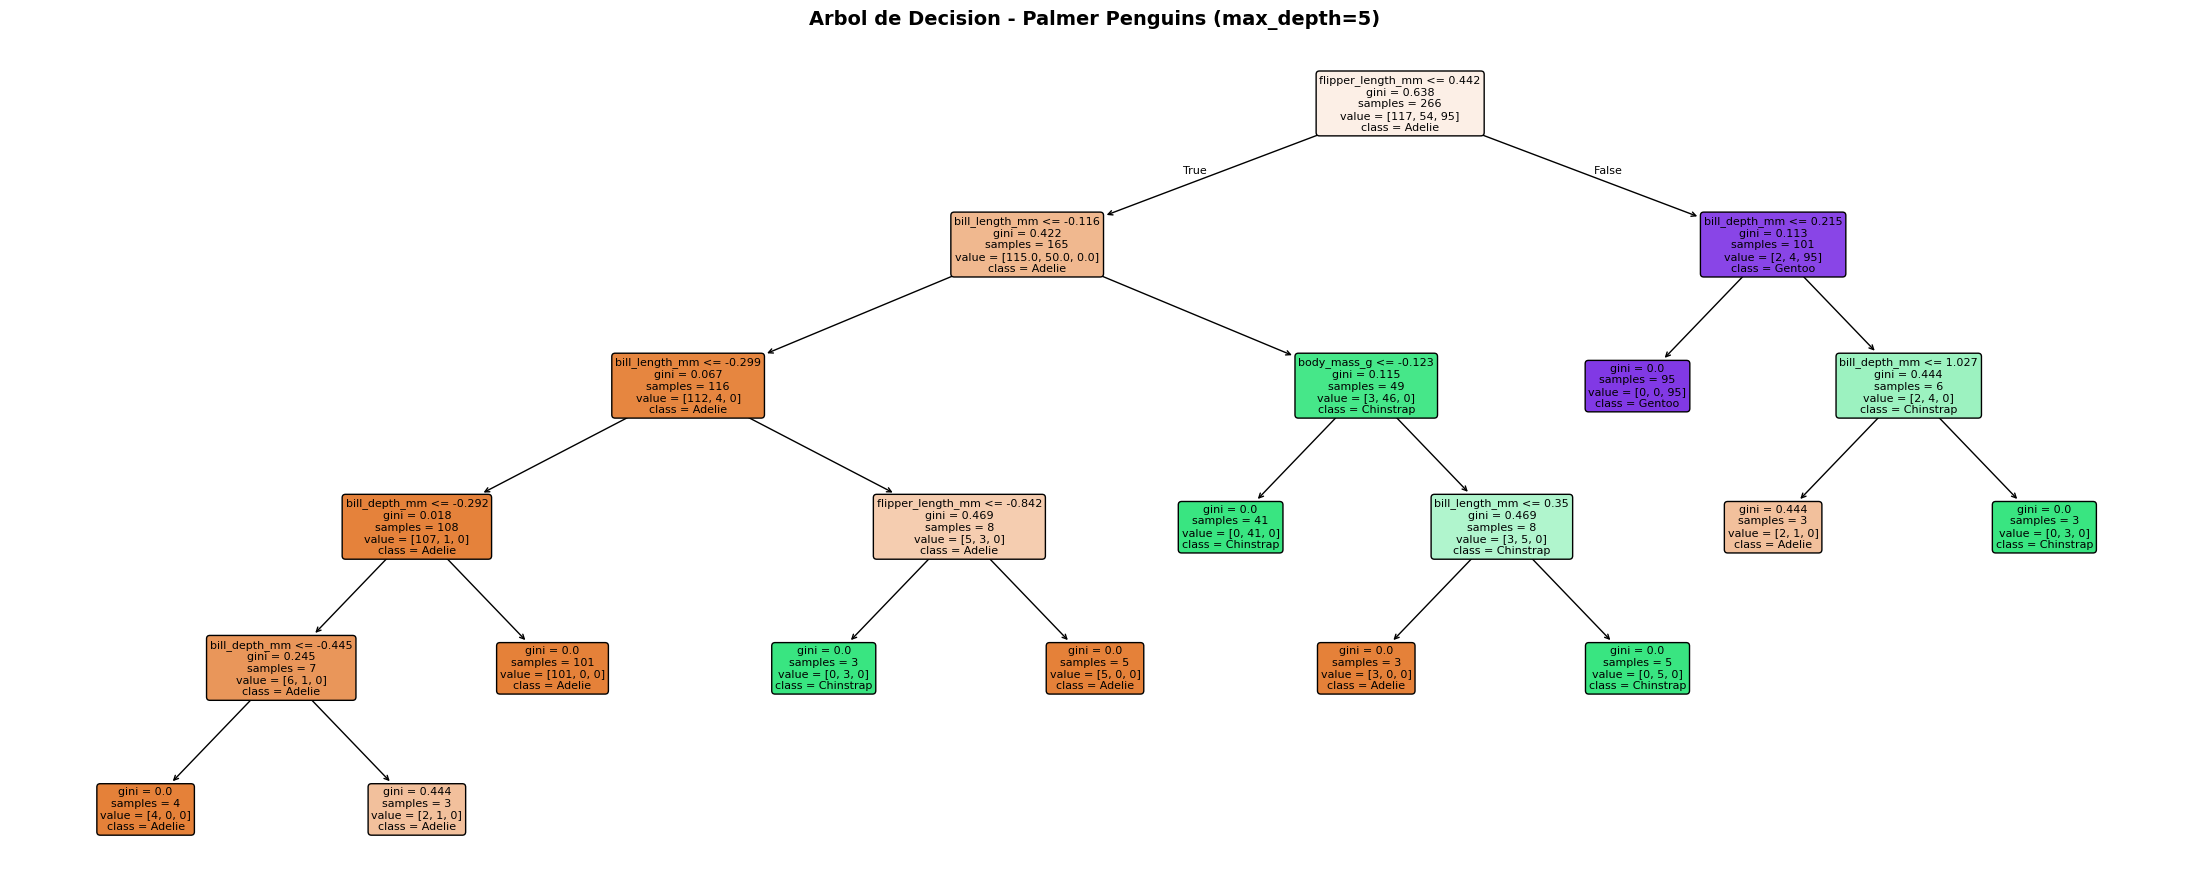

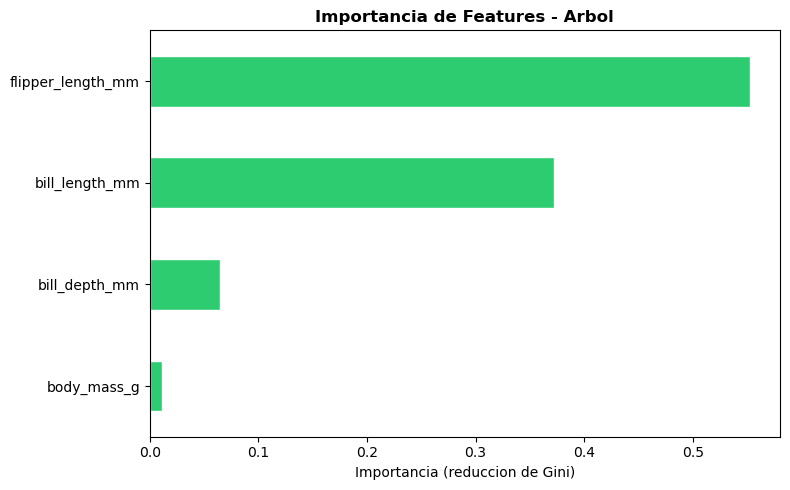


Variable mas determinante: flipper_length_mm (0.552)
Profundidad real: 5 | Hojas: 11


In [78]:
# -- Analisis de profundidad vs accuracy --------------------------
# Justificamos la eleccion de max_depth=5 mostrando su efecto
depths     = range(1, 11)
train_accs = []
test_accs  = []

for d in depths:
    t = DecisionTreeClassifier(max_depth=d, criterion='gini', random_state=42)
    t.fit(X_train, y_train)
    train_accs.append(accuracy_score(y_train, t.predict(X_train)))
    test_accs.append(accuracy_score(y_test,  t.predict(X_test)))

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(depths, train_accs, marker='o', color='#3498db', label='Train Accuracy', linewidth=2)
ax.plot(depths, test_accs,  marker='o', color='#2ecc71', label='Test Accuracy',  linewidth=2)
ax.axvline(x=5, color='#e74c3c', linestyle='--', alpha=0.7, label='max_depth elegido (5)')
ax.set_title('Accuracy vs Profundidad del Arbol', fontweight='bold')
ax.set_xlabel('max_depth'); ax.set_ylabel('Accuracy')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

print("Por que max_depth=5?")
print(f"  A partir de depth 5, Test Accuracy se estabiliza o baja.")
print(f"  Profundidades mayores aumentan Train pero no Test: eso es OVERFITTING.")
print(f"  max_depth=5 es el punto de equilibrio entre complejidad y generalizacion.")

# -- Entrenamiento final ------------------------------------------
arbol = DecisionTreeClassifier(max_depth=5, criterion='gini', min_samples_leaf=3, random_state=42)
arbol.fit(X_train, y_train)
y_pred_arbol = arbol.predict(X_test)

print_metrics(y_test, y_pred_arbol, "Arbol de Decision")
plot_confusion_matrix(y_test, y_pred_arbol, "Matriz de Confusion - Arbol")

# -- Visualizar arbol --------------------------------------------
plt.figure(figsize=(22, 9))
plot_tree(arbol, feature_names=feature_names, class_names=class_names,
          filled=True, rounded=True, fontsize=8, impurity=True)
plt.title("Arbol de Decision - Palmer Penguins (max_depth=5)", fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

# -- Importancia de features -------------------------------------
importances = pd.Series(arbol.feature_importances_, index=feature_names)
importances_sorted = importances[importances > 0].sort_values()

plt.figure(figsize=(8, 5))
importances_sorted.plot(kind='barh', color='#2ecc71', edgecolor='white')
plt.title('Importancia de Features - Arbol', fontweight='bold')
plt.xlabel('Importancia (reduccion de Gini)')
plt.tight_layout(); plt.show()

top_feature = importances.idxmax()
print(f"\nVariable mas determinante: {top_feature} ({importances.max():.3f})")
print(f"Profundidad real: {arbol.get_depth()} | Hojas: {arbol.get_n_leaves()}")

### ⚠️ Limitaciones del Árbol → ¿Por qué necesitamos algo más?

1. **Overfitting latente:** La gráfica de profundidad muestra que a partir de cierto punto el árbol memoriza el entrenamiento sin mejorar en test.
2. **Fronteras rectangulares:** Solo puede cortar en "mayor/menor que X" — no captura bien límites curvos.
3. **Probabilidades poco confiables:** Reporta proporción de la hoja, no una estimación probabilística real.

> 💡 Necesitamos **probabilidades calibradas y reales** — **Regresión Logística Multinomial**.

---
## 🟠 Bloque 6: Regresión Logística Multinomial (RLM)


**El flujo es:**
1. Calcula una combinación lineal de features: `zₖ = w₁·x₁ + w₂·x₂ + ... + bₖ`
2. Aplica **softmax**: convierte esos valores en probabilidades que suman 1
3. Predice la clase con mayor probabilidad → **clasificación**

### Ventajas sobre el Árbol
- ✅ Probabilidades calibradas y reales (no solo proporciones de una hoja)
- ✅ Más estable: cambios pequeños en datos no cambian el modelo drásticamente
- ✅ Coeficientes interpretables: cada variable tiene un peso asignado


  Metricas - Regresion Logistica Multinomial
  Accuracy         : 0.9851  (98.5%)
  Balanced Accuracy: 0.9885  (98.9%)
  F1-Macro         : 0.9827
  Precision        : 0.9778
  Recall           : 0.9885
  Accuracy y Balanced Accuracy son similares: el modelo no favorece clases mayoritarias de forma significativa.
  
  Desempeño excelente para este dataset.


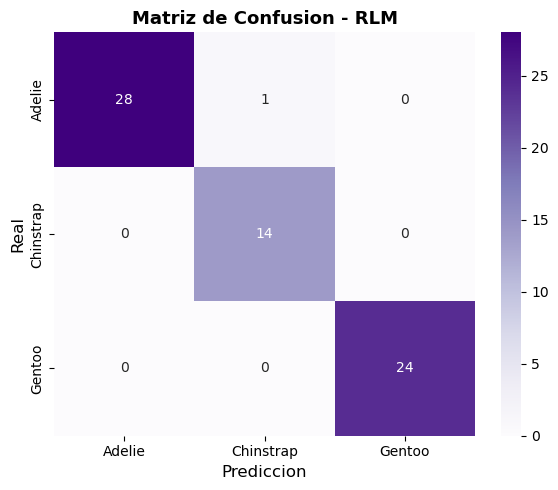


Como leer esta matriz:
  La diagonal principal = predicciones correctas.
  Valores fuera de diagonal = errores (confusion entre clases).
  Total aciertos: 66/67 (98.5%)
  - Adelie: 28 correctos, 1 confundidos
  - Chinstrap: 14 correctos, 0 confundidos
  - Gentoo: 24 correctos, 0 confundidos

Probabilidades predichas (primeras 8 muestras del test):


,Real,Prediccion,Adelie,Chinstrap,Gentoo,Correcto
0,Gentoo,Gentoo,0.0002,0.0116,0.9882,True
1,Chinstrap,Chinstrap,0.0231,0.9703,0.0066,True
2,Adelie,Adelie,0.9904,0.0088,0.0009,True
3,Gentoo,Gentoo,0.0005,0.0042,0.9953,True
4,Gentoo,Gentoo,0.0009,0.0073,0.9918,True
5,Gentoo,Gentoo,0.0164,0.0028,0.9808,True
6,Chinstrap,Chinstrap,0.0086,0.9882,0.0032,True
7,Adelie,Adelie,0.9991,0.0001,0.0008,True



Coeficientes por clase:


,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,island_Biscoe,island_Dream,island_Torgersen,sex_Female,sex_Male
Adelie,-2.336,0.803,-0.615,-0.262,0.030,-0.320,0.395,-0.390,0.390
Chinstrap,1.919,0.191,-0.251,-0.564,-0.686,0.884,-0.239,0.322,-0.322
Gentoo,0.417,-0.993,0.866,0.826,0.656,-0.564,-0.156,0.068,-0.068



Como leer los coeficientes:

La RLM asigna un peso a cada variable para cada especie.
  - Coeficiente positivo: esa variable AUMENTA la probabilidad de esa especie.
  - Coeficiente negativo: esa variable REDUCE la probabilidad.
  - Mayor magnitud (positiva o negativa): mayor influencia en la decision.

Ejemplo practico:
  Si flipper_length_mm tiene coeficiente alto y positivo para Gentoo, significa que a mayor longitud de aleta, mayor probabilidad de Gentoo.
  Esto coincide con lo observado en el EDA.

Ventaja sobre el Arbol: las probabilidades aqui son reales y calibradas.
Si el modelo dice 87% Gentoo, significa que de casos similares aproximadamente el 87% son realmente Gentoo.



In [79]:
rlm = LogisticRegression(solver='lbfgs', max_iter=1000, C=1.0, random_state=42)
rlm.fit(X_train, y_train)

y_pred_rlm = rlm.predict(X_test)
y_prob_rlm = rlm.predict_proba(X_test)

print_metrics(y_test, y_pred_rlm, "Regresion Logistica Multinomial")
plot_confusion_matrix(y_test, y_pred_rlm, "Matriz de Confusion - RLM")

# -- Probabilidades de las primeras predicciones -----------------
print("\nProbabilidades predichas (primeras 8 muestras del test):")
prob_df = pd.DataFrame(y_prob_rlm[:8], columns=class_names).round(4)
prob_df.insert(0, 'Real',       [class_names[r] for r in y_test[:8]])
prob_df.insert(1, 'Prediccion', [class_names[p] for p in y_pred_rlm[:8]])
prob_df['Correcto'] = prob_df['Real'] == prob_df['Prediccion']
display(prob_df)

# -- Coeficientes del modelo -------------------------------------
print("\nCoeficientes por clase:")
coef_df = pd.DataFrame(rlm.coef_, columns=feature_names, index=class_names)
display(coef_df.round(3))

print("""
Como leer los coeficientes:

La RLM asigna un peso a cada variable para cada especie.
  - Coeficiente positivo: esa variable AUMENTA la probabilidad de esa especie.
  - Coeficiente negativo: esa variable REDUCE la probabilidad.
  - Mayor magnitud (positiva o negativa): mayor influencia en la decision.

Ejemplo practico:
  Si flipper_length_mm tiene coeficiente alto y positivo para Gentoo, significa que a mayor longitud de aleta, mayor probabilidad de Gentoo.
  Esto coincide con lo observado en el EDA.

Ventaja sobre el Arbol: las probabilidades aqui son reales y calibradas.
Si el modelo dice 87% Gentoo, significa que de casos similares aproximadamente el 87% son realmente Gentoo.
""")

### ⚠️ Limitaciones de RLM → ¿Por qué necesitamos algo más?

1. **Linealidad estricta:** Las fronteras son hiperplanos. Si la separación real requiere curvas, RLM no puede aprenderlas.
2. **Sin representaciones intermedias:** Usa las features tal como son; no aprende combinaciones abstractas.

> 💡 Para capturar relaciones **no lineales** y aprender patrones complejos, necesitamos capas ocultas — **Red Neuronal (MLP)**.

---
## 🟣 Bloque 7: Red Neuronal — Perceptrón Multicapa (MLP)

### Arquitectura
```
Entrada (11) → Oculta (64, ReLU) → Oculta (32, ReLU) → Salida (3, Softmax)
```

### ¿Cómo aprende?
1. **Forward pass:** datos fluyen capa a capa: `output = activación(W·x + b)`
2. **Loss:** error entre predicción y etiqueta (cross-entropy)
3. **Backpropagation:** gradientes calculados hacia atrás
4. **Adam optimizer:** ajusta pesos para minimizar el error
5. Repite por épocas hasta convergencia

---

> 💡 **Nota — Complejidad de hacerlo desde cero:**  
> Implementar este MLP manualmente implicaría matrices `W₁` (11×64), `W₂` (64×32), `W₃` (32×3), implementar ReLU y softmax, programar backpropagation completo con derivadas parciales por capa, codificar Adam con sus momentos, y gestionar el ciclo de épocas con mini-batches.  
> Viable para 1 neurona binaria (como en el ejercicio de cáncer de mama), prohibitivo para 2 capas ocultas y 3 clases sin librerías.  
> `MLPClassifier` de sklearn hace todo eso internamente.


  Metricas - Red Neuronal (MLP)
  Accuracy         : 0.9701  (97.0%)
  Balanced Accuracy: 0.9524  (95.2%)
  F1-Macro         : 0.9632
  Precision        : 0.9785
  Recall           : 0.9524
  Accuracy y Balanced Accuracy son similares: el modelo no favorece clases mayoritarias de forma significativa.
  
  Desempeño excelente para este dataset.

Arquitectura: Entrada(9) -> Oculta(64,ReLU) -> Oculta(32,ReLU) -> Salida(3,Softmax)
Epocas hasta convergencia: 40
Parametros totales: 2819


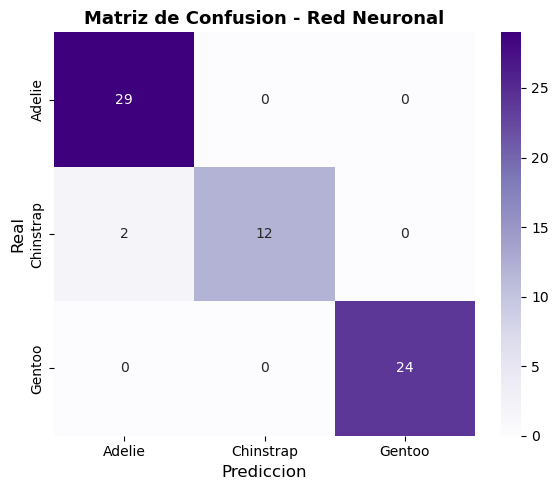


Como leer esta matriz:
  La diagonal principal = predicciones correctas.
  Valores fuera de diagonal = errores (confusion entre clases).
  Total aciertos: 65/67 (97.0%)
  - Adelie: 29 correctos, 0 confundidos
  - Chinstrap: 12 correctos, 2 confundidos
  - Gentoo: 24 correctos, 0 confundidos


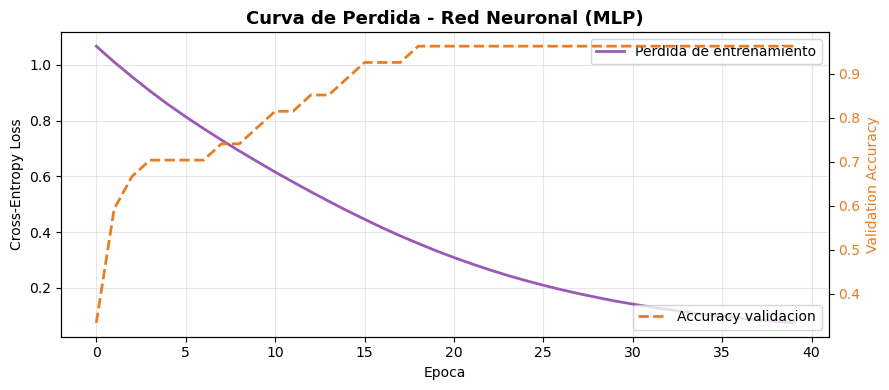


Como leer estas curvas:

  - Linea morada (loss de entrenamiento): debe bajar con cada epoca.
    Una curva que desciende rapido y se estabiliza = entrenamiento saludable.

  - Linea naranja (accuracy de validacion): debe subir y estabilizarse.
    Si la loss baja pero la validacion no sube, hay overfitting.

  - El early stopping detiene el entrenamiento cuando la validacion
    deja de mejorar, evitando memorizar el dataset de entrenamiento.



In [80]:
mlp = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',
    max_iter=1000,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=20
)
mlp.fit(X_train, y_train)
y_pred_mlp = mlp.predict(X_test)

print_metrics(y_test, y_pred_mlp, "Red Neuronal (MLP)")
print(f"\nArquitectura: Entrada({X_train.shape[1]}) -> Oculta(64,ReLU) -> Oculta(32,ReLU) -> Salida(3,Softmax)")
print(f"Epocas hasta convergencia: {mlp.n_iter_}")
print(f"Parametros totales: {sum(w.size for w in mlp.coefs_) + sum(b.size for b in mlp.intercepts_)}")

plot_confusion_matrix(y_test, y_pred_mlp, "Matriz de Confusion - Red Neuronal")

# -- Curva de perdida (train + validacion) -----------------------
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(mlp.loss_curve_, color='#9b59b6', linewidth=2, label='Perdida de entrenamiento')

# validation_scores_ contiene accuracy de validacion por epoca (cuando early_stopping=True)
if hasattr(mlp, 'validation_scores_') and mlp.validation_scores_ is not None:
    ax2 = ax.twinx()
    ax2.plot(mlp.validation_scores_, color='#e67e22', linewidth=2,
             linestyle='--', label='Accuracy validacion')
    ax2.set_ylabel('Validation Accuracy', color='#e67e22')
    ax2.tick_params(axis='y', labelcolor='#e67e22')
    ax2.legend(loc='lower right')

ax.set_title('Curva de Perdida - Red Neuronal (MLP)', fontsize=13, fontweight='bold')
ax.set_xlabel('Epoca'); ax.set_ylabel('Cross-Entropy Loss')
ax.legend(loc='upper right'); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

print("""
Como leer estas curvas:

  - Linea morada (loss de entrenamiento): debe bajar con cada epoca.
    Una curva que desciende rapido y se estabiliza = entrenamiento saludable.

  - Linea naranja (accuracy de validacion): debe subir y estabilizarse.
    Si la loss baja pero la validacion no sube, hay overfitting.

  - El early stopping detiene el entrenamiento cuando la validacion
    deja de mejorar, evitando memorizar el dataset de entrenamiento.
""")

---
## 🧠 Bloque 8a: Generalización y Overfitting

Antes de comparar los modelos, es importante entender un concepto que afecta a todos ellos.

============ GENERALIZACION Y OVERFITTING ============

Un modelo no debe solo memorizar los datos de entrenamiento.
El objetivo real es aprender PATRONES GENERALES que funcionen bien con datos nuevos que nunca ha visto.

QUE ES OVERFITTING?
  Ocurre cuando un modelo es demasiado complejo y se ajusta a los datos de entrenamiento con tal precision que pierde capacidad de generalizar.
  Señal tipica: Train Accuracy alta, Test Accuracy baja.

MODELOS MAS PROPENSOS AL OVERFITTING EN ESTE NOTEBOOK:
  - Arbol de Decision (sin restriccion de profundidad)
  - Red Neuronal MLP (con muchas epocas o capas)

COMO LO CONTROLAMOS:
  - Arbol: max_depth=5 y min_samples_leaf=3
    (visto en la grafica de accuracy vs profundidad)
  - MLP: early_stopping=True
    (detiene cuando la validacion deja de mejorar)
  - Todos: train/test split estratificado
    (evaluamos en datos que el modelo nunca vio)
  - RLM y SVM: regularizacion implicita (parametro C)

UN MODELO UTIL NO ES EL QUE TIENE 100% EN TRAIN.
ES EL QUE FUNCIONA BIEN EN DATOS NUEVOS.

======================================================

---
## 📊 Bloque 8b: Tabla Comparativa de Modelos

Tabla Comparativa de Modelos


,Accuracy,Bal.Acc,F1-Macro,Precision,Recall
Modelo,,,,,
SVM (kernel RBF),0.9851,0.9885,0.9827,0.9778,0.9885
Regresion Logistica Multinomial,0.9851,0.9885,0.9827,0.9778,0.9885
Red Neuronal (MLP),0.9701,0.9524,0.9632,0.9785,0.9524
Arbol de Decision,0.9552,0.9607,0.9518,0.9468,0.9607
K-Means,0.7910,0.6667,0.6019,0.5581,0.6667


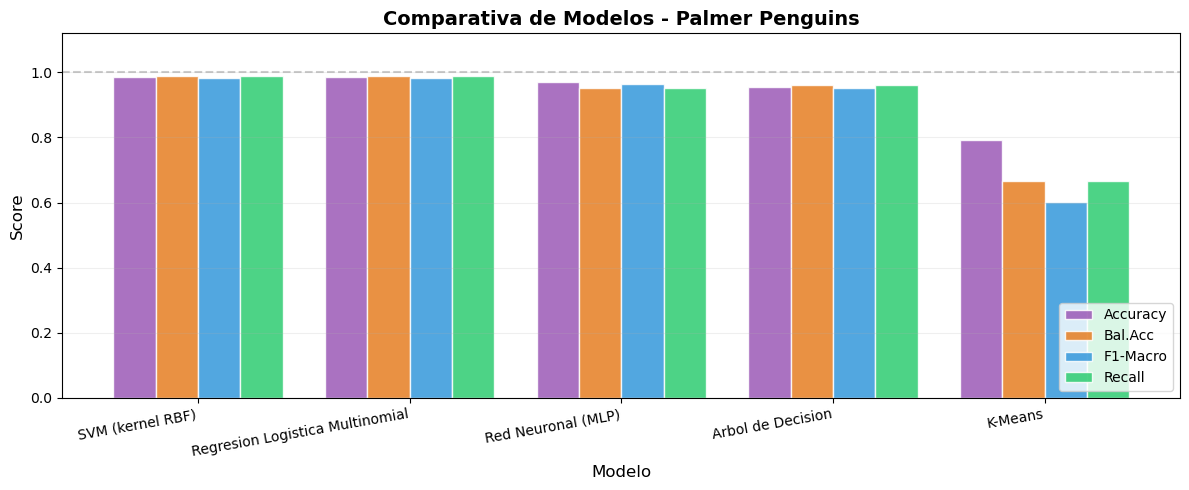


Modelo con mayor accuracy: SVM (kernel RBF) (98.5%)
Modelo con menor accuracy: K-Means  (79.1%)

Diferencia Accuracy vs Balanced Accuracy por modelo:
  SVM (kernel RBF): 0.0034
  Regresion Logistica Multinomial: 0.0034
  Red Neuronal (MLP): 0.0177
  Arbol de Decision: 0.0055
  K-Means: 0.1243  <- atento: posible sesgo hacia clases mayoritarias


In [81]:
df_res = pd.DataFrame(resultados).T
df_res.index.name = 'Modelo'
df_res = df_res.sort_values('Accuracy', ascending=False)

print("Tabla Comparativa de Modelos")
display(df_res.style
        .background_gradient(cmap='Purples', axis=0)
        .format("{:.4f}")
        .set_caption("Metricas evaluadas en test (20% de los datos)"))

# -- Grafica de barras -------------------------------------------
metricas = ['Accuracy', 'Bal.Acc', 'F1-Macro', 'Recall']
colors   = ['#9b59b6', '#e67e22', '#3498db', '#2ecc71']
x     = np.arange(len(df_res))
width = 0.2

fig, ax = plt.subplots(figsize=(12, 5))
for i, (met, color) in enumerate(zip(metricas, colors)):
    ax.bar(x + i*width, df_res[met], width, label=met, color=color, alpha=0.85, edgecolor='white')

ax.set_xlabel('Modelo', fontsize=12); ax.set_ylabel('Score', fontsize=12)
ax.set_title('Comparativa de Modelos - Palmer Penguins', fontsize=14, fontweight='bold')
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(df_res.index, rotation=10, ha='right')
ax.legend(loc='lower right')
ax.set_ylim(0, 1.12)
ax.axhline(y=1.0, color='gray', linestyle='--', alpha=0.4)
ax.grid(True, alpha=0.2, axis='y')
plt.tight_layout(); plt.show()

mejor = df_res['Accuracy'].idxmax()
peor  = df_res['Accuracy'].idxmin()
print(f"\nModelo con mayor accuracy: {mejor} ({df_res.loc[mejor,'Accuracy']:.1%})")
print(f"Modelo con menor accuracy: {peor}  ({df_res.loc[peor,'Accuracy']:.1%})")

# -- Diferencia entre Accuracy y Balanced Accuracy ---------------
print("\nDiferencia Accuracy vs Balanced Accuracy por modelo:")
diff = (df_res['Accuracy'] - df_res['Bal.Acc']).abs()
for m, d in diff.items():
    flag = "  <- atento: posible sesgo hacia clases mayoritarias" if d > 0.03 else ""
    print(f"  {m}: {d:.4f}{flag}")

============ ELECCION DEL MODELO ============

Aunque varios modelos obtuvieron resultados altos, la eleccion depende del objetivo del proyecto.

SEGUN EL OBJETIVO:

  Si necesitamos EXPLICAR cada prediccion:
    - Arbol de Decision o RLM
    - Puedes mostrar la regla exacta o el coeficiente que llevo a la decision.

  Si necesitamos MAXIMA PRECISION:
    - SVM o MLP
    - Son mas flexibles pero menos explicables.

  Si NO tienes etiquetas:
    - K-Means para explorar agrupamientos naturales.
    - Punto de partida antes de etiquetar datos.

  Si necesitamos PROBABILIDADES CONFIABLES:
    - RLM (las mas calibradas matematicamente)
    - MLP (flexible, buenas probabilidades)
    
    
  No siempre se elige el modelo mas preciso.
  Se elige el mas util para el contexto:
    - Medico: quiero explicar por que diagnostico X
    - Produccion masiva: quiero maxima precision
    - Datos sin etiquetar: K-Means primero, luego supervisado

En este caso, RLM o MLP son candidatos finales:
alta precision + probabilidades reales.

=============================================

---
## 🔮 Bloque 9: Demo de Inferencia

Demostramos que los modelos funcionan con datos completamente nuevos.

> 🐧 **Pingüino de prueba:** Isla Dream · Pico 46mm largo / 15mm profundo · Aleta 215mm · Masa 4,800g · Macho  
> *(características típicas de Gentoo)*

In [82]:
nuevo_raw = {
    'bill_length_mm': 46.0, 'bill_depth_mm': 15.0,
    'flipper_length_mm': 215.0, 'body_mass_g': 4800.0,
    'island_Biscoe': 0, 'island_Dream': 1, 'island_Torgersen': 0,
    'sex_Female': 0, 'sex_Male': 1,
}

X_nuevo        = pd.DataFrame([nuevo_raw])[feature_names].values.astype(float)
X_nuevo_scaled = scaler.transform(X_nuevo)

print("Predicciones para el pinguino nuevo")
print("="*68)

# K-Means (sin probabilidades)
cluster_nuevo  = kmeans.predict(X_nuevo_scaled)[0]
especie_kmeans = class_names[label_map.get(int(cluster_nuevo), int(cluster_nuevo))]
print(f"  {'K-Means':<30}: Cluster {cluster_nuevo} -> {especie_kmeans}")
print(f"  (K-Means NO genera probabilidades: solo asignacion determinista de cluster)")

# Modelos con probabilidades
modelos_prob = {
    "SVM (kernel RBF)":          svm,
    "Arbol de Decision":         arbol,
    "Regresion Logistica (RLM)": rlm,
    "Red Neuronal (MLP)":        mlp,
}

pred_rows = []
for nombre, modelo in modelos_prob.items():
    pred  = modelo.predict(X_nuevo_scaled)[0]
    proba = modelo.predict_proba(X_nuevo_scaled)[0]
    clase = class_names[pred]
    p_str = "  |  ".join([f"{class_names[i]}: {proba[i]:.1%}" for i in range(3)])
    print(f"  {nombre:<30}: {clase:<12}  [{p_str}]")
    pred_rows.append({'Modelo': nombre, 'Prediccion': clase,
                      **{class_names[i]: f"{proba[i]:.1%}" for i in range(3)}})

print("="*68)
print("\nTabla de probabilidades:")
display(pd.DataFrame(pred_rows).set_index('Modelo'))

Predicciones para el pinguino nuevo
  K-Means                       : Cluster 2 -> Adelie
  (K-Means NO genera probabilidades: solo asignacion determinista de cluster)
  SVM (kernel RBF)              : Adelie        [Adelie: 42.3%  |  Chinstrap: 36.8%  |  Gentoo: 20.8%]
  Arbol de Decision             : Gentoo        [Adelie: 0.0%  |  Chinstrap: 0.0%  |  Gentoo: 100.0%]
  Regresion Logistica (RLM)     : Gentoo        [Adelie: 5.0%  |  Chinstrap: 31.2%  |  Gentoo: 63.8%]
  Red Neuronal (MLP)            : Gentoo        [Adelie: 36.4%  |  Chinstrap: 25.0%  |  Gentoo: 38.7%]

Tabla de probabilidades:


,Prediccion,Adelie,Chinstrap,Gentoo
Modelo,,,,
SVM (kernel RBF),Adelie,42.3%,36.8%,20.8%
Arbol de Decision,Gentoo,0.0%,0.0%,100.0%
Regresion Logistica (RLM),Gentoo,5.0%,31.2%,63.8%
Red Neuronal (MLP),Gentoo,36.4%,25.0%,38.7%


---
## ✅ Bloque 10: Conclusiones

| Modelo | Supervisado | Interpretable | Probabilidades | Complejidad |
|--------|:-----------:|:-------------:|:--------------:|:-----------:|
| K-Means | ❌ | ⚠️ clusters | ❌ | ⬇️ Baja |
| SVM | ✅ | ❌ | ✅ | ⬆️ Media |
| Árbol | ✅ | ✅✅ | ⚠️ aprox. | ⬇️ Baja |
| RLM | ✅ | ✅ | ✅✅ | ⬇️ Baja |
| MLP | ✅ | ❌ | ✅ | ⬆️⬆️ Alta |

1. EDA
   Las tres especies presentan diferencias claras en variables fisicas. 
   Gentoo es la mas distinguible;
   Adelie y Chinstrap tienen mayor traslape.
   La correlacion entre masa corporal y longitud de aleta fue aprovechada por los modelos supervisados.

2. OVERFITTING Y GENERALIZACION
   Se controlo mediante: max_depth en el Arbol, early stopping en MLP, y regularizacion en SVM y RLM.
   La grafica de profundidad vs accuracy del Arbol demostro visualmente el efecto del overfitting.

3. DESEMPENO DE MODELOS
   Los modelos supervisados mejoran consistentemente sobre K-Means al usar las etiquetas reales.
   RLM y MLP obtuvieron los mejores resultados generales, con probabilidades calibradas por clase.

4. VARIABLES MAS IMPORTANTES
   Coincidiendo con el EDA:
   - body_mass_g y flipper_length_mm -> clave para Gentoo
   - bill_length_mm -> distingue Chinstrap de Adelie

5. CONCLUSION FINAL
   El dataset Palmer Penguins es adecuado para clasificacion supervisada multiclase.
   El enfoque progresivo permite justificar cada incremento de complejidad, mostrando que la eleccion del modelo no solo depende de la precision, sino del contexto, la interpretabilidad requerida y la confianza en las probabilidades predichas.
